<a href="https://colab.research.google.com/github/Fjmoya-uba/Taller-Procesamiento-Se-ales/blob/main/TPs/TPS_03_Francisco_Javier_Moya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°3 de TPS: Regresión Polinómica

Este TP trata de reconocer comandos de voz de forma automática. Para eso, se toman audios, se los transforma en una representación más útil usando la STFT y bandas de energía, y luego esas características se usan para entrenar una regresión logística que clasifique qué palabra fue dicha.


Se importan las librerías y las bibliotecas que se usarán.

In [1]:
import os
import requests
import tarfile
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import glob
import random
import numpy as np


## Ítem A: Preprocesamiento

En esta primera parte del trabajo práctico se prepara la información que después se usará para clasificar comandos de voz. Para eso, primero se descargan y exploran algunos audios de la base de datos, observando su forma de onda y escuchándolos para familiarizarse con las señales. Luego, cada audio se analiza en el dominio tiempo-frecuencia mediante la transformada de Fourier de corto tiempo (STFT), usando ventanas de 512 puntos con 50\% de solapamiento y ventana de Hann. A partir de ese espectro, se resume la información dividiéndolo en 20 bandas de frecuencia y calculando la energía en cada una. Finalmente, esas energías se expresan en decibeles, obteniendo así una representación más compacta y adecuada para las etapas posteriores de clasificación.

### Punto 1

Se descarga de manera autocontenida la base de datos.

In [2]:
# --- PUNTO A.1: Descargar y descomprimir la base de datos ---
url = "http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz"
target_path = "speech_commands_v0.02.tar.gz"
extract_folder = "speech_data"

if not os.path.exists(extract_folder):
    print("Descargando base de datos... ")
    response = requests.get(url, stream=True)
    with open(target_path, "wb") as f:
        f.write(response.raw.read())

    print("Extrayendo archivos...")
    with tarfile.open(target_path, "r:gz") as tar:
        tar.extractall(path=extract_folder)
    print("¡Proceso completado!")
else:
    print("La base de datos ya existe localmente.")

Descargando base de datos... 
Extrayendo archivos...


/tmp/ipykernel_672/1020663418.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_folder)


¡Proceso completado!


### Puntos 2 y 3

Se seleccionan tres audios al azar, se grafican en el dominio del tiempo y luego se reproducen.

Audio 1: speech_data/happy/1ed0b13d_nohash_0.wav [Punto A.2]


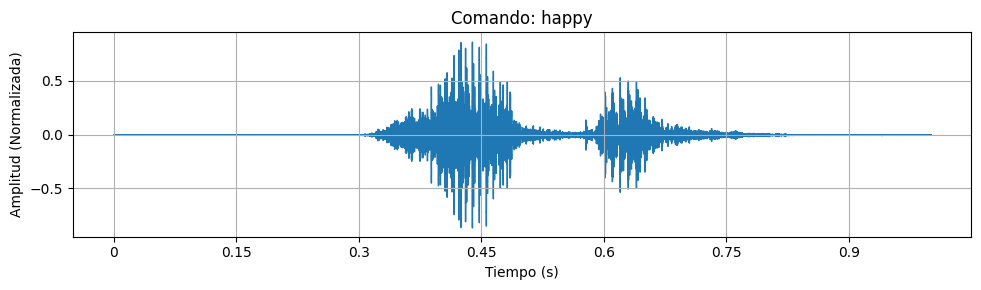

Audio 2: speech_data/backward/51c5601d_nohash_2.wav [Punto A.2]


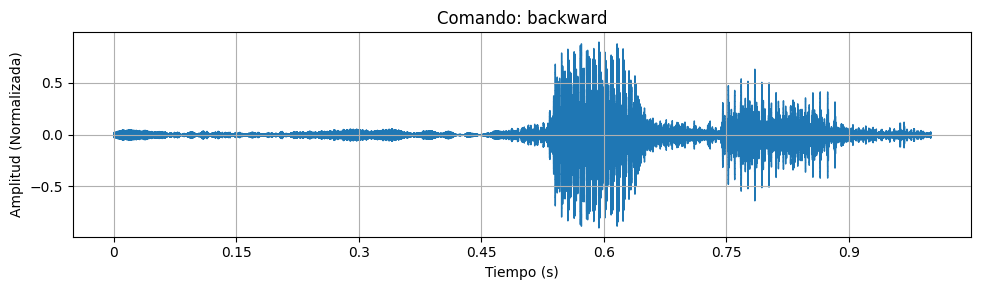

Audio 3: speech_data/forward/d0745d72_nohash_0.wav [Punto A.2]


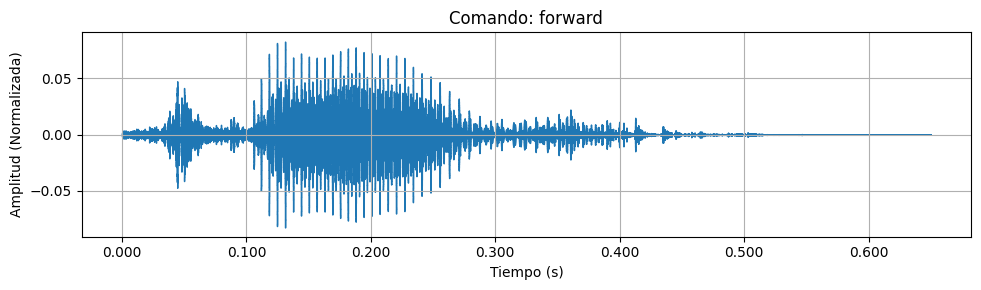

In [3]:
# --- PUNTO A.2: Cargar al menos tres audios utilizando librosa ---
audio_files = glob.glob(os.path.join(extract_folder, "*/*.wav"))
samples_to_load = random.sample(audio_files, 3)

for i, path in enumerate(samples_to_load):
    y, sr = librosa.load(path, sr=None)
    print(f"Audio {i+1}: {path} [Punto A.2]")

    # --- PUNTO A.3: Reproducir y Graficar (ahora con labels) ---
    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(y, sr=sr)

    plt.title(f"Comando: {os.path.basename(os.path.dirname(path))}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud (Normalizada)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    ipd.display(ipd.Audio(y, rate=sr)) # [Punto A.3]

En los gráficos de las formas de onda se observa que la amplitud toma valores positivos y negativos. Esto se debe a que el micrófono convierte variaciones de presión del aire en una señal eléctrica y la señal oscila alrededor de cero. Cuando la curva va positiva, la tensión instantánea está para un lado de la referencia, cuando va negativa, está para el otro lado. En términos prácticos, lo importante es la magnitud de la amplitud y su evolución temporal, ya que eso refleja la energía y la estructura de la palabra pronunciada.

Además, al cargar los audios se utilizó `librosa.load(path, sr=None)`. Esto es importante porque los archivos originales de la base están muestreados a 16 kHz, y si no se especifica `sr=None`, `librosa` los remuestrea automáticamente a 22.05 kHz. Aunque eso no necesariamente rompe el análisis, sí modifica innecesariamente los datos originales, por lo que conviene mantener la frecuencia de muestreo original del dataset.

### Punto 4

En esta parte del TP el objetivo es pasar del audio crudo a una representación que muestre cómo se reparte la energía en frecuencia a medida que pasa el tiempo. Para eso se usa la STFT: en vez de calcular una sola transformada de Fourier para todo el audio, se divide la señal en tramos cortos y se calcula una FFT en cada uno. Esto es necesario porque una palabra no es estacionaria, las frecuencias presentes al principio, en el medio y al final no son las mismas. Por eso interesa mirar el contenido espectral localmente en el tiempo y no solo en promedio.

En señales de voz suelen usarse ventanas de entre 20 y 40 ms porque, en intervalos tan cortos, la señal puede considerarse aproximadamente estacionaria o cuasiestacionaria: su contenido espectral no cambia demasiado dentro de esa ventana. Eso permite que la FFT tenga sentido como una descripción local del sonido. Si la ventana fuera mucho más larga, mezclaría partes distintas de la palabra y se perdería información temporal importante. Mientras que si fuera demasiado corta, la resolución en frecuencia sería muy pobre. En este caso, usar `n_fft = 512` con \($f_s = 16\text{ kHz}$\) equivale a una ventana de 32 ms, que cae dentro de ese rango típico. La resolución en frecuencia resultante es de \($16000/512 = 31.25$\) Hz, que es suficiente para este TP porque no se busca medir frecuencias exactas con gran precisión, sino capturar cómo se distribuye la energía espectral de la voz y cómo esa distribución cambia en el tiempo. En otras palabras, para distinguir palabras no alcanza con mirar solo el tiempo ni solo la frecuencia: interesa una representación tiempo-frecuencia que conserve ambas cosas de manera equilibrada.

Por otro lado, las ventanas se toman con 50\% de solapamiento, es decir, cada nueva ventana empieza a mitad de la anterior. Esto se hace para no “saltearse” información entre bloques consecutivos y para que la representación cambie de forma más suave en el tiempo. Si no hubiera solapamiento, podrían perderse transiciones importantes entre sonidos.

Antes de hacer cada FFT se aplica una ventana de Hann. La idea es suavizar los bordes de cada tramo, porque cortar la señal de golpe genera discontinuidades artificiales que ensucian el espectro. La ventana de Hann reduce ese efecto y hace que la energía quede mejor ubicada en las frecuencias donde realmente está. Como la señal de audio es real, el espectro tiene una parte simétrica, así que solo hace falta trabajar con una mitad.


In [4]:
# --- PUNTO A.4: Calcular la transformada de Fourier de corto tiempo (STFT) ---
def calcular_stft_tp(y):
    # Configuración: FFT 512, Solapamiento 50% (hop 256), Ventana Hann 512
    # Librosa descarta la parte simétrica automáticamente para señales reales.
    stft = librosa.stft(y, n_fft=512, hop_length=256, win_length=512, window='hann', center=False)
    return np.abs(stft)**2 # Retornamos magnitud al cuadrado (energía)


Se utiliza `center=False` en la STFT para evitar el padding automático que `librosa` agrega por defecto en los extremos de la señal. Cuando `center=True`, cada ventana queda centrada respecto del instante temporal representado, pero eso implica extender artificialmente la señal con ceros al principio y al final, modificando la cantidad de ventanas obtenidas. En este trabajo práctico se usa `center=False` porque así la STFT se calcula únicamente sobre las muestras reales del audio, y la cantidad de ventanas temporales queda determinada de forma directa por la longitud de la señal, el tamaño de la ventana y el salto entre ventanas.

### Punto 5


Luego, en lugar de usar todos los bins de frecuencia, el espectro se resume en 20 bandas de energía.

Después de la STFT se obtiene una representación tiempo-frecuencia bastante detallada, con muchos bins de frecuencia en cada instante. Esa descripción contiene información útil, pero también un nivel de detalle que no necesariamente hace falta para reconocer comandos de voz. Por eso, en lugar de usar todo el espectro, se agrupan bins vecinos en 20 bandas y se resume cada una por su energía. De esta forma se reduce la cantidad de datos y se conserva lo más importante para la clasificación: cómo se distribuye la energía en frecuencia y cómo esa distribución cambia con el tiempo. En otras palabras, se baja la resolución espectral, pero tratando de mantener la información más relevante para distinguir una palabra de otra.


In [5]:
# --- PUNTO A.5: Descomponer el espectro en 20 bandas de energía ---
def calcular_bandas_20(espectro):
    n_bins, n_frames = espectro.shape
    n_bandas = 20
    bins_por_banda = n_bins // n_bandas

    energias = np.zeros((n_bandas, n_frames))
    for i in range(n_bandas):
        inicio = i * bins_por_banda
        fin = (i + 1) * bins_por_banda
        # Sumatoria de |X[k]|^2 para la banda i-ésima
        energias[i, :] = np.sum(espectro[inicio:fin, :], axis=0)
    return energias


### Punto 6


Esas energías se convierten a dB para trabajar en una escala logarítmica más cómoda. Esto permite comprimir el rango dinámico de la señal, evitando que las bandas con mucha energía tapen numéricamente a las más débiles. Así, la comparación entre distintas partes del espectro resulta más clara y la representación final queda mejor adaptada para las etapas posteriores de clasificación.

In [6]:
# --- PUNTO A.6: Convertir la energía en dB ---
def energia_a_db(E):
    E_max = np.max(E)
    eps = 1e-10 # Epsilon para evitar log(0)
    # Fórmula: 10 * log10(E / E_max)
    return 10 * np.log10((E + eps) / (E_max + eps))

### Resultado del preprocesamiento

En esta celda se aplica todo el flujo del inciso (A) a un único audio de ejemplo. Es decir, se toma una señal, se calcula su STFT, luego se resume el espectro en 20 bandas de energía y finalmente esas energías se convierten a dB. El resultado es una matriz donde cada columna representa una ventana temporal y cada fila una banda de frecuencia (son 20 filas en total).

Procesamiento finalizado. Matriz resultante: (20, 63)


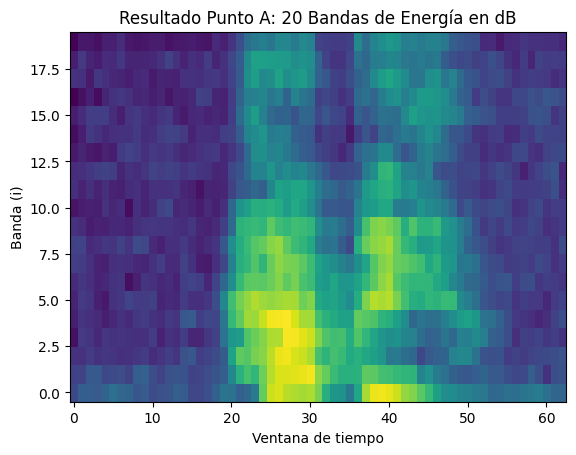

In [7]:
# Demostración del flujo completo del Inciso (a)
audio_test, sr_test = librosa.load(samples_to_load[0], sr=None)

# Ejecución secuencial de los puntos 4, 5 y 6
espectro_pot = calcular_stft_tp(audio_test)      # Punto 4
bandas_raw = calcular_bandas_20(espectro_pot)   # Punto 5
bandas_db = energia_a_db(bandas_raw)            # Punto 6

print(f"Procesamiento finalizado. Matriz resultante: {bandas_db.shape}")
plt.imshow(bandas_db, aspect='auto', origin='lower')
plt.title("Resultado Punto A: 20 Bandas de Energía en dB")
plt.ylabel("Banda (i)")
plt.xlabel("Ventana de tiempo")
plt.show()



La representación obtenida tiene menos resolución que un espectrograma clásico, ya que en lugar de conservar todos los bins de frecuencia se agrupa la información en solo 20 bandas. Esto hace que la visualización se vea más “gruesa” o resumida, pero justamente ese es el objetivo: reducir la cantidad de datos y conservar una descripción compacta de cómo se distribuye la energía de la palabra en frecuencia y en el tiempo. Aunque visualmente tenga menos detalle, esta representación resulta más adecuada para usar luego como entrada del clasificador.

## Ítem B: Clasificación binaria de comandos de voz

En este inciso del trabajo práctico se construye un clasificador capaz de distinguir entre dos comandos: `yes` y `no`. Para eso, primero se arma una base de datos con esos audios y se unifica su longitud, de modo que todos generen la misma cantidad de ventanas temporales al aplicar el preprocesamiento. Luego, cada audio se transforma en una matriz de características de tamaño \($50 \times 20$\), que resume cómo se distribuye su energía en frecuencia a lo largo del tiempo. Finalmente, esas características se usan para entrenar una regresión logística binaria implementada desde cero, y se evalúa su desempeño sobre datos de entrenamiento y de prueba.

### Puntos 1 y 2

En esta etapa se empieza a construir el problema de clasificación. En lugar de trabajar con todos los comandos de la base, se seleccionan únicamente los audios correspondientes a las palabras `yes` y `no`. Cada audio se asocia a una etiqueta numérica (`yes = 0`, `no = 1`), de modo que el objetivo posterior será entrenar un modelo que, dado un audio, pueda decidir automáticamente a cuál de estas dos clases pertenece.

Como los audios originales no tienen exactamente la misma duración, es necesario unificarlos para que todos generen la misma cantidad de datos al aplicar el preprocesamiento del punto A. Para eso se fija una longitud objetivo en muestras y se ajusta cada audio de la siguiente manera:
- si es más largo, se recorta al final,
- si es más corto, se completa con ceros (*zero-padding*).

Para que todos los audios generen exactamente 50 ventanas temporales, la cantidad de ventanas viene dada por:

$$
N_{\text{frames}} = 1 + \left\lfloor \frac{L - 512}{256} \right\rfloor
$$

Donde \($L$\) es la longitud del audio en muestras. Imponiendo \($N_{\text{frames}}=50$\), se obtiene:

$$
L = 512 + 49\cdot 256 = 13056
$$

Por eso se fija `target_samples = 13056`: así, luego del recorte o zero-padding, todos los audios producen exactamente 50 ventanas al aplicar la STFT.
En resumen, en este paso se arma la base de datos binaria (`yes` vs `no`) y se asegura que todos los audios tengan el mismo formato de entrada para las etapas siguientes.

In [8]:
# --- PUNTO B.1 y B.2: Carga y unificación de audios ---

target_samples = 13056
clases = ['yes', 'no']
X_raw = []
y_labels = []

print("Iniciando carga de audios y unificación de largos...")

for label_idx, clase in enumerate(clases):
    clase_path = os.path.join("speech_data", clase)
    archivos = [f for f in os.listdir(clase_path) if f.endswith('.wav')]

    for archivo in archivos:
        path = os.path.join(clase_path, archivo)
        # Se carga el audio usando la función de librosa del punto A
        y, sr = librosa.load(path, sr=None)

        # Ajuste de longitud [Punto B.2]
        if len(y) > target_samples:
            y = y[:target_samples]  # Recorte al final
        elif len(y) < target_samples:
            y = np.pad(y, (0, target_samples - len(y)), mode='constant')  # Zero-padding

        X_raw.append(y)
        y_labels.append(label_idx) # yes=0, no=1

X_raw = np.array(X_raw)
y_labels = np.array(y_labels)

print(f"Base de datos construida: {len(X_raw)} muestras en total.")

Iniciando carga de audios y unificación de largos...
Base de datos construida: 7985 muestras en total.


### Punto 3

In [9]:
# --- PUNTO B.3 y B.4: Preprocesamiento y aplanado ---

features = []

print("Extrayendo bandas de energía en dB...")

for audio in X_raw:
    # Se reutilizan las funciones del Punto A
    espectro = calcular_stft_tp(audio)
    bandas = calcular_bandas_20(espectro)
    bandas_db = energia_a_db(bandas)

    # Se asegura que el tamaño sea (20, 50). Si sobra una ventana por redondeo, se recorta.
    bandas_db = bandas_db[:, :50]

    # Aplanado de la muestra (1000 características por audio)
    features.append(bandas_db.flatten())

X = np.array(features)
y = y_labels

print(f"Matriz de características final: {X.shape} (Muestras, Features)")

Extrayendo bandas de energía en dB...
Matriz de características final: (7985, 1000) (Muestras, Features)


### Punto 4

In [10]:
# --- PUNTO B.4: División entrenamiento y testeo (80/20) ---

indices = np.arange(len(X))
np.random.shuffle(indices)

split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Entrenamiento: {X_train.shape[0]} muestras. Testeo: {X_test.shape[0]} muestras.")

Entrenamiento: 6388 muestras. Testeo: 1597 muestras.


### Punto 5

In [11]:
# --- PUNTO B.5: Clase BinaryLogisticRegression ---

class BinaryLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        # Implementación estable para evitar overflow
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        for _ in range(self.n_iters):
            # Modelo lineal + activación sigmoide
            model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(model)

            # Gradientes
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Actualización de parámetros
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Guardar la pérdida de la iteración actual
            self.loss_history.append(self.cross_entropy(X, y))

    def predict_proba(self, X):
        model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(model)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

    def cross_entropy(self, X, y):
        y_pred = self.predict_proba(X)
        epsilon = 1e-15 # Evita log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

### Puntos 6 y 7

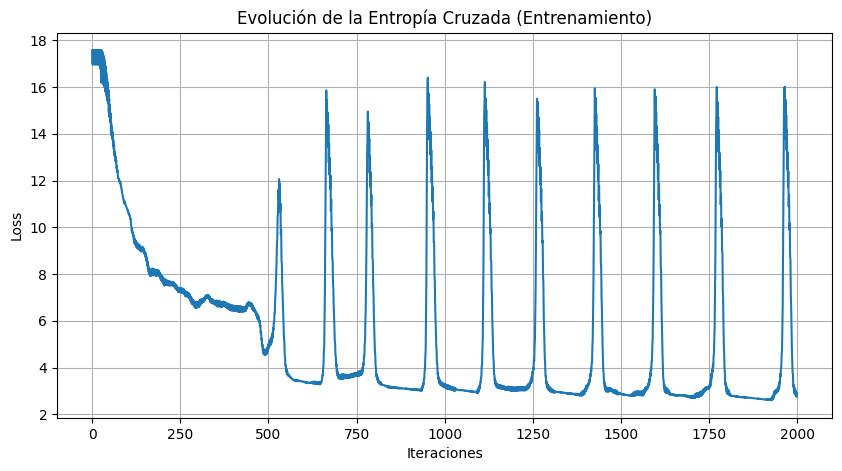

Train Accuracy: 0.9184
Test Accuracy:  0.9192
Train Cross-Entropy: 2.7564
Test Cross-Entropy:  2.6839


In [12]:
# --- PUNTO B.6 y B.7: Entrenamiento y Gráficos ---

# Se recomienda ajustar estos hiperparámetros según la convergencia visual
modelo = BinaryLogisticRegression(learning_rate=0.005, n_iters=2000)
modelo.fit(X_train, y_train)

# Gráfico de convergencia [Punto B.6]
plt.figure(figsize=(10, 5))
plt.plot(modelo.loss_history)
plt.title("Evolución de la Entropía Cruzada (Entrenamiento)")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Reporte de métricas [Punto B.7]
print(f"Train Accuracy: {modelo.accuracy(X_train, y_train):.4f}")
print(f"Test Accuracy:  {modelo.accuracy(X_test, y_test):.4f}")
print(f"Train Cross-Entropy: {modelo.cross_entropy(X_train, y_train):.4f}")
print(f"Test Cross-Entropy:  {modelo.cross_entropy(X_test, y_test):.4f}")

## Ítem C